In [ ]:
!pip install -q requests pillow scikit-learn seaborn tensorflow


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
os.makedirs(PROJECT_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:

import os
import time
import requests

PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
RAW_DATA_DIR = os.path.join(PROJECT_DIR, 'data_raw')

SPECIES = [
    "Sri Lankan leopard",
    "Asian elephant",
    "Sloth bear",
    "Spotted deer",
    "Sambar deer",
    "Mugger crocodile",
    "Sri Lankan peacock",
    "Grey langur",
    "Water buffalo",
    "Indian python",
    "Crested serpent eagle",
    "Wild boar",
    "Bengal monitor lizard",
]

IMAGES_PER_SPECIES = 200
PHOTO_SIZE = "medium"
MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK = 100

INATURALIST_API = "https://api.inaturalist.org/v1"


def get_sri_lanka_place_id():
    resp = requests.get(
        f"{INATURALIST_API}/places/autocomplete",
        params={"q": "Sri Lanka"},
    )
    resp.raise_for_status()
    results = resp.json()["results"]
    for place in results:
        if place["display_name"].strip().lower() == "sri lanka":
            return place["id"]
    return results[0]["id"]


def get_taxon_id(species_name):
    resp = requests.get(
        f"{INATURALIST_API}/taxa",
        params={"q": species_name, "per_page": 1, "rank": "species"},
    )
    resp.raise_for_status()
    results = resp.json()["results"]
    if not results:
        print(f"  WARNING: no taxon found for '{species_name}'")
        return None
    return results[0]["id"], results[0].get("name")


def download_species_images(species_name, taxon_id, place_id, target_count,
                              out_dir, start_index=0, source_tag="SL"):

    os.makedirs(out_dir, exist_ok=True)
    downloaded = 0
    page = 1
    per_page = 50

    while downloaded < target_count:
        params = {
            "taxon_id": taxon_id,
            "photos": "true",
            "quality_grade": "research",
            "per_page": per_page,
            "page": page,
        }
        if place_id is not None:
            params["place_id"] = place_id

        resp = requests.get(f"{INATURALIST_API}/observations", params=params)
        resp.raise_for_status()
        data = resp.json()
        results = data.get("results", [])

        if not results:
            print(f"    No more observations available from this source "
                  f"(got {downloaded}/{target_count} in this call)")
            break

        for obs in results:
            if downloaded >= target_count:
                break
            for photo in obs.get("photos", []):
                if downloaded >= target_count:
                    break
                url = photo["url"].replace("square", PHOTO_SIZE)
                try:
                    img_resp = requests.get(url, timeout=15)
                    if img_resp.status_code == 200:
                        file_index = start_index + downloaded
                        filename = os.path.join(
                            out_dir,
                            f"{species_name.replace(' ', '_')}_{source_tag}_{file_index:04d}.jpg",
                        )
                        with open(filename, "wb") as f:
                            f.write(img_resp.content)
                        downloaded += 1
                except requests.RequestException:
                    continue

        page += 1
        time.sleep(1)

    return downloaded


                                                                           
def main():
    print("Looking up Sri Lanka place_id...")
    place_id = get_sri_lanka_place_id()
    print(f"Sri Lanka place_id = {place_id}\n")

    summary = {}

    for species in SPECIES:
        print(f"Processing: {species}")
        taxon_result = get_taxon_id(species)
        if taxon_result is None:
            summary[species] = {"sri_lanka": 0, "global": 0}
            continue

        taxon_id, matched_name = taxon_result
        print(f"  Matched iNaturalist taxon: '{matched_name}' (id={taxon_id})")

        species_folder = os.path.join(RAW_DATA_DIR, species.replace(" ", "_"))


        print(f"  Searching Sri Lanka-tagged observations...")
        sl_count = download_species_images(
            species_name=species,
            taxon_id=taxon_id,
            place_id=place_id,
            target_count=IMAGES_PER_SPECIES,
            out_dir=species_folder,
            start_index=0,
            source_tag="SL",
        )
        print(f"    -> {sl_count} Sri Lanka-tagged images")


        global_count = 0
        if sl_count < MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK:
            remaining = IMAGES_PER_SPECIES - sl_count
            print(f"    Sri Lanka-tagged images below "
                  f"{MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK} -- "
                  f"topping up with {remaining} global images...")
            global_count = download_species_images(
                species_name=species,
                taxon_id=taxon_id,
                place_id=None,
                target_count=remaining,
                out_dir=species_folder,
                start_index=sl_count,
                source_tag="GLOBAL",
            )
            print(f"    -> {global_count} global images added")
        else:
            print(f"    Sri Lanka-tagged images sufficient, no fallback needed")

        total = sl_count + global_count
        summary[species] = {"sri_lanka": sl_count, "global": global_count}
        print(f"  Total for '{species}': {total} images "
              f"({sl_count} Sri Lanka + {global_count} global)\n")

    print("=" * 70)
    print("DOWNLOAD SUMMARY")
    print("=" * 70)
    print(f"{'Species':30s} {'Sri Lanka':>10s} {'Global':>8s} {'Total':>8s}")
    for species, counts in summary.items():
        total = counts["sri_lanka"] + counts["global"]
        flag = "  <-- LOW, consider supplementing manually" if total < 80 else ""
        print(f"{species:30s} {counts['sri_lanka']:>10d} {counts['global']:>8d} "
              f"{total:>8d}{flag}")


if __name__ == "__main__":
    main()


Looking up Sri Lanka place_id...
Sri Lanka place_id = 7077

Processing: Sri Lankan leopard
Processing: Asian elephant
  Matched iNaturalist taxon: 'Elephas maximus' (id=43697)
  Searching Sri Lanka-tagged observations...
    -> 200 Sri Lanka-tagged images
    Sri Lanka-tagged images sufficient, no fallback needed
  Total for 'Asian elephant': 200 images (200 Sri Lanka + 0 global)

Processing: Sloth bear
  Matched iNaturalist taxon: 'Melursus ursinus' (id=41651)
  Searching Sri Lanka-tagged observations...
    -> 200 Sri Lanka-tagged images
    Sri Lanka-tagged images sufficient, no fallback needed
  Total for 'Sloth bear': 200 images (200 Sri Lanka + 0 global)

Processing: Spotted deer
  Matched iNaturalist taxon: 'Axis axis' (id=42166)
  Searching Sri Lanka-tagged observations...
    -> 200 Sri Lanka-tagged images
    Sri Lanka-tagged images sufficient, no fallback needed
  Total for 'Spotted deer': 200 images (200 Sri Lanka + 0 global)

Processing: Sambar deer
  Matched iNaturalist t

In [ ]:

import os
import time
import requests

                                                                           
PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
RAW_DATA_DIR = os.path.join(PROJECT_DIR, 'data_raw')

SPECIES = [
    {"display_name": "Sri Lankan leopard",      "search_query": "Panthera pardus kotiya"},
    {"display_name": "Asian elephant",          "search_query": "Asian elephant"},
    {"display_name": "Sloth bear",               "search_query": "Sloth bear"},
    {"display_name": "Spotted deer",             "search_query": "Spotted deer"},
    {"display_name": "Sambar deer",              "search_query": "Sambar deer"},
                                                                     
                                                                       
                                                
    {"display_name": "Mugger crocodile",         "search_query": "Mugger crocodile"},
    {"display_name": "Sri Lankan peacock",       "search_query": "Indian peafowl"},
    {"display_name": "Sri Lankan grey langur",   "search_query": "Semnopithecus priam thersites"},
    {"display_name": "Water buffalo",            "search_query": "Water buffalo"},
    {"display_name": "Indian python",            "search_query": "Indian python"},
    {"display_name": "Crested serpent eagle",    "search_query": "Crested serpent eagle"},
    {"display_name": "Wild boar",                "search_query": "Wild boar"},
    {"display_name": "Bengal monitor lizard",    "search_query": "Bengal monitor lizard"},
]
                                                                          
                                                                       
                                                                         
                                         
                                                                          
                                                                       
                                                       
                                                                     
                                                                     
                                                                       
                                                              
                                                                        
                                                                         
                                                                        
                                                   

IMAGES_PER_SPECIES = 300                                                  
                                                                         
                                                                      
PHOTO_SIZE = "medium"                                                                 

                                                                         
                                                                        
                                                                         
                                                                  
                                                                      
                                            
MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK = 100

INATURALIST_API = "https://api.inaturalist.org/v1"


                                                                             
def get_sri_lanka_place_id():
    resp = requests.get(
        f"{INATURALIST_API}/places/autocomplete",
        params={"q": "Sri Lanka"},
    )
    resp.raise_for_status()
    results = resp.json()["results"]
    for place in results:
        if place["display_name"].strip().lower() == "sri lanka":
            return place["id"]
                                                                 
    return results[0]["id"]


                                                                             
def get_taxon_id(search_query):
    """
    Looks up a taxon by name on iNaturalist. Does NOT restrict to
    rank=species, since some entries we care about (e.g. the Sri Lankan
    leopard, Panthera pardus kotiya) are subspecies -- restricting to
    species rank would silently fail to find them, exactly as happened
    in the first run of this script.
    """
    resp = requests.get(
        f"{INATURALIST_API}/taxa",
        params={"q": search_query, "per_page": 5},
    )
    resp.raise_for_status()
    results = resp.json()["results"]
    if not results:
        print(f"  WARNING: no taxon found for '{search_query}'")
        return None

                                                                     
                                                       
    preferred_ranks = {"species", "subspecies"}
    for r in results:
        if r.get("rank") in preferred_ranks:
            return r["id"], r.get("name"), r.get("rank")

                                                                     
    return results[0]["id"], results[0].get("name"), results[0].get("rank")


                                                                             
def download_species_images(species_name, taxon_id, place_id, target_count,
                              out_dir, start_index=0, source_tag="SL"):

    os.makedirs(out_dir, exist_ok=True)
    downloaded = 0
    page = 1
    per_page = 50

    while downloaded < target_count:
        params = {
            "taxon_id": taxon_id,
            "photos": "true",
            "quality_grade": "research",
            "per_page": per_page,
            "page": page,
        }
        if place_id is not None:
            params["place_id"] = place_id

        resp = requests.get(f"{INATURALIST_API}/observations", params=params)
        resp.raise_for_status()
        data = resp.json()
        results = data.get("results", [])

        if not results:
            print(f"    No more observations available from this source "
                  f"(got {downloaded}/{target_count} in this call)")
            break

        for obs in results:
            if downloaded >= target_count:
                break
            for photo in obs.get("photos", []):
                if downloaded >= target_count:
                    break
                url = photo["url"].replace("square", PHOTO_SIZE)
                try:
                    img_resp = requests.get(url, timeout=15)
                    if img_resp.status_code == 200:
                        file_index = start_index + downloaded
                        filename = os.path.join(
                            out_dir,
                            f"{species_name.replace(' ', '_')}_{source_tag}_{file_index:04d}.jpg",
                        )
                        with open(filename, "wb") as f:
                            f.write(img_resp.content)
                        downloaded += 1
                except requests.RequestException:
                    continue

        page += 1
        time.sleep(1)                                                    

    return downloaded


                                                                           
def main():
    print("Looking up Sri Lanka place_id...")
    place_id = get_sri_lanka_place_id()
    print(f"Sri Lanka place_id = {place_id}\n")

    summary = {}

    for entry in SPECIES:
        display_name = entry["display_name"]
        search_query = entry["search_query"]

        print(f"Processing: {display_name}", end="")
        if search_query != display_name:
            print(f"  (searching iNaturalist as: '{search_query}')")
        else:
            print()

        taxon_result = get_taxon_id(search_query)
        if taxon_result is None:
            summary[display_name] = {"sri_lanka": 0, "global": 0}
            print(f"  SKIPPED -- check the search_query for this species "
                  f"and try a different name (e.g. its scientific name)\n")
            continue

        taxon_id, matched_name, matched_rank = taxon_result
        print(f"  Matched iNaturalist taxon: '{matched_name}' "
              f"(id={taxon_id}, rank={matched_rank})")

                                                                            
                                                                           
                                      
        species_folder = os.path.join(RAW_DATA_DIR, display_name.replace(" ", "_"))

                                                                          
                                                                      
                                                                        
                                                  
        existing_count = 0
        if os.path.isdir(species_folder):
            existing_count = len([
                f for f in os.listdir(species_folder)
                if os.path.isfile(os.path.join(species_folder, f))
            ])
        if existing_count >= IMAGES_PER_SPECIES:
            print(f"  SKIPPED -- already have {existing_count} images "
                  f"in '{species_folder}'\n")
            summary[display_name] = {"sri_lanka": existing_count, "global": 0}
            continue

                                                                        
                                                                  
        print(f"  Searching Sri Lanka-tagged observations...")
        sl_count = download_species_images(
            species_name=display_name,
            taxon_id=taxon_id,
            place_id=place_id,
            target_count=IMAGES_PER_SPECIES,
            out_dir=species_folder,
            start_index=0,
            source_tag="SL",
        )
        print(f"    -> {sl_count} Sri Lanka-tagged images")

                                                                     
                                                                     
                                             
        global_count = 0
        if sl_count < MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK:
            remaining = IMAGES_PER_SPECIES - sl_count
            print(f"    Sri Lanka-tagged images below "
                  f"{MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK} -- "
                  f"topping up with {remaining} global images...")
            global_count = download_species_images(
                species_name=display_name,
                taxon_id=taxon_id,
                place_id=None,                                            
                target_count=remaining,
                out_dir=species_folder,
                start_index=sl_count,                                  
                source_tag="GLOBAL",
            )
            print(f"    -> {global_count} global images added")
        else:
            print(f"    Sri Lanka-tagged images sufficient, no fallback needed")

        total = sl_count + global_count
        summary[display_name] = {"sri_lanka": sl_count, "global": global_count}
        print(f"  Total for '{display_name}': {total} images "
              f"({sl_count} Sri Lanka + {global_count} global)\n")

    print("=" * 70)
    print("DOWNLOAD SUMMARY")
    print("=" * 70)
    print(f"{'Species':30s} {'Sri Lanka':>10s} {'Global':>8s} {'Total':>8s}")
    for display_name, counts in summary.items():
        total = counts["sri_lanka"] + counts["global"]
        flag = "  <-- LOW, consider supplementing manually" if total < 80 else ""
        print(f"{display_name:30s} {counts['sri_lanka']:>10d} {counts['global']:>8d} "
              f"{total:>8d}{flag}")


if __name__ == "__main__":
    main()

Looking up Sri Lanka place_id...
Sri Lanka place_id = 7077

Processing: Sri Lankan leopard  (searching iNaturalist as: 'Panthera pardus kotiya')
  Matched iNaturalist taxon: 'Panthera pardus kotiya' (id=147732, rank=subspecies)
  Searching Sri Lanka-tagged observations...
    -> 300 Sri Lanka-tagged images
    Sri Lanka-tagged images sufficient, no fallback needed
  Total for 'Sri Lankan leopard': 300 images (300 Sri Lanka + 0 global)

Processing: Asian elephant
  Matched iNaturalist taxon: 'Elephas maximus' (id=43697, rank=species)
  Searching Sri Lanka-tagged observations...
    -> 300 Sri Lanka-tagged images
    Sri Lanka-tagged images sufficient, no fallback needed
  Total for 'Asian elephant': 300 images (300 Sri Lanka + 0 global)

Processing: Sloth bear
  Matched iNaturalist taxon: 'Melursus ursinus' (id=41651, rank=species)
  Searching Sri Lanka-tagged observations...
    -> 300 Sri Lanka-tagged images
    Sri Lanka-tagged images sufficient, no fallback needed
  Total for 'Sloth

In [ ]:


import os
import time
import requests

                                                                           
PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
RAW_DATA_DIR = os.path.join(PROJECT_DIR, 'data_raw')

SPECIES = [
    {"display_name": "Sri Lankan leopard",      "search_query": "Panthera pardus kotiya"},
    {"display_name": "Asian elephant",          "search_query": "Asian elephant"},
    {"display_name": "Sloth bear",               "search_query": "Sloth bear"},
    {"display_name": "Spotted deer",             "search_query": "Spotted deer"},
    {"display_name": "Sambar deer",              "search_query": "Sambar deer"},
                                                                     
                                                                       
                                                
    {"display_name": "Mugger crocodile",         "search_query": "Mugger crocodile"},
    {"display_name": "Sri Lankan peacock",       "search_query": "Indian peafowl"},
    {"display_name": "Sri Lankan grey langur",   "search_query": "Semnopithecus priam thersites"},
    {"display_name": "Water buffalo",            "search_query": "Water buffalo"},
    {"display_name": "Golden jackal",            "search_query": ["Golden jackal", "Indian rock python"]},
                                                                          
                                                                     
                                                                       
                                                                       
                                                                 
                                    
    {"display_name": "Crested serpent eagle",    "search_query": "Crested serpent eagle"},
    {"display_name": "Wild boar",                "search_query": "Wild boar"},
    {"display_name": "Bengal monitor lizard",    "search_query": "Bengal monitor lizard"},
]
                                                                          
                                                                       
                                                                         
                                         
                                                                          
                                                                       
                                                       
                                                                     
                                                                     
                                                                       
                                                              
                                                                        
                                                                         
                                                                        
                                                   

IMAGES_PER_SPECIES = 300                                                  
                                                                         
                                                                      
PHOTO_SIZE = "medium"                                                                 

                                                                         
                                                                        
                                                                         
                                                                  
                                                                      
                                            
MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK = 100

                                                                      
                                                                        
                                                                     
                                                                     
                                                                      
MIN_TOTAL_IMAGES_BEFORE_TRYING_NEXT_CANDIDATE = 150

INATURALIST_API = "https://api.inaturalist.org/v1"


                                                                             
def get_sri_lanka_place_id():
    resp = requests.get(
        f"{INATURALIST_API}/places/autocomplete",
        params={"q": "Sri Lanka"},
    )
    resp.raise_for_status()
    results = resp.json()["results"]
    for place in results:
        if place["display_name"].strip().lower() == "sri lanka":
            return place["id"]
                                                                 
    return results[0]["id"]


                                                                             
def get_taxon_id(search_query):
    """
    Looks up a taxon by name on iNaturalist. Does NOT restrict to
    rank=species, since some entries we care about (e.g. the Sri Lankan
    leopard, Panthera pardus kotiya) are subspecies -- restricting to
    species rank would silently fail to find them, exactly as happened
    in the first run of this script.
    """
    resp = requests.get(
        f"{INATURALIST_API}/taxa",
        params={"q": search_query, "per_page": 5},
    )
    resp.raise_for_status()
    results = resp.json()["results"]
    if not results:
        print(f"  WARNING: no taxon found for '{search_query}'")
        return None

                                                                     
                                                       
    preferred_ranks = {"species", "subspecies"}
    for r in results:
        if r.get("rank") in preferred_ranks:
            return r["id"], r.get("name"), r.get("rank")

                                                                     
    return results[0]["id"], results[0].get("name"), results[0].get("rank")


                                                                             
def download_species_images(species_name, taxon_id, place_id, target_count,
                              out_dir, start_index=0, source_tag="SL"):

    os.makedirs(out_dir, exist_ok=True)
    downloaded = 0
    page = 1
    per_page = 50

    while downloaded < target_count:
        params = {
            "taxon_id": taxon_id,
            "photos": "true",
            "quality_grade": "research",
            "per_page": per_page,
            "page": page,
        }
        if place_id is not None:
            params["place_id"] = place_id

        resp = requests.get(f"{INATURALIST_API}/observations", params=params)
        resp.raise_for_status()
        data = resp.json()
        results = data.get("results", [])

        if not results:
            print(f"    No more observations available from this source "
                  f"(got {downloaded}/{target_count} in this call)")
            break

        for obs in results:
            if downloaded >= target_count:
                break
            for photo in obs.get("photos", []):
                if downloaded >= target_count:
                    break
                url = photo["url"].replace("square", PHOTO_SIZE)
                try:
                    img_resp = requests.get(url, timeout=15)
                    if img_resp.status_code == 200:
                        file_index = start_index + downloaded
                        filename = os.path.join(
                            out_dir,
                            f"{species_name.replace(' ', '_')}_{source_tag}_{file_index:04d}.jpg",
                        )
                        with open(filename, "wb") as f:
                            f.write(img_resp.content)
                        downloaded += 1
                except requests.RequestException:
                    continue

        page += 1
        time.sleep(1)                                                    

    return downloaded


                                                                              
def try_one_candidate(search_query, display_name, place_id, species_folder,
                       target_count):
    """
    Attempts the full Sri-Lanka-first-then-global download strategy for
    ONE candidate search name. Returns (sl_count, global_count, taxon_info)
    so the caller can decide whether this candidate was good enough or
    whether to move on to the next name in the list.
    """
    taxon_result = get_taxon_id(search_query)
    if taxon_result is None:
        print(f"    WARNING: no taxon found for candidate '{search_query}'")
        return 0, 0, None

    taxon_id, matched_name, matched_rank = taxon_result
    print(f"    Matched iNaturalist taxon: '{matched_name}' "
          f"(id={taxon_id}, rank={matched_rank})")

    print(f"    Searching Sri Lanka-tagged observations...")
    sl_count = download_species_images(
        species_name=display_name,
        taxon_id=taxon_id,
        place_id=place_id,
        target_count=target_count,
        out_dir=species_folder,
        start_index=0,
        source_tag="SL",
    )
    print(f"      -> {sl_count} Sri Lanka-tagged images")

    global_count = 0
    if sl_count < MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK:
        remaining = target_count - sl_count
        print(f"      Below {MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK} -- "
              f"topping up with {remaining} global images...")
        global_count = download_species_images(
            species_name=display_name,
            taxon_id=taxon_id,
            place_id=None,
            target_count=remaining,
            out_dir=species_folder,
            start_index=sl_count,
            source_tag="GLOBAL",
        )
        print(f"      -> {global_count} global images added")

    return sl_count, global_count, (matched_name, matched_rank)


                                                                           
def main():
    print("Looking up Sri Lanka place_id...")
    place_id = get_sri_lanka_place_id()
    print(f"Sri Lanka place_id = {place_id}\n")

    summary = {}

    for entry in SPECIES:
        display_name = entry["display_name"]
        search_queries = entry["search_query"]
                                                                          
                                                                         
                                   
        if isinstance(search_queries, str):
            search_queries = [search_queries]

        print(f"Processing: {display_name}")

        species_folder = os.path.join(RAW_DATA_DIR, display_name.replace(" ", "_"))

                                                                          
                                                                           
        existing_count = 0
        if os.path.isdir(species_folder):
            existing_count = len([
                f for f in os.listdir(species_folder)
                if os.path.isfile(os.path.join(species_folder, f))
            ])
        if existing_count >= IMAGES_PER_SPECIES:
            print(f"  SKIPPED -- already have {existing_count} images "
                  f"in '{species_folder}'\n")
            summary[display_name] = {"sri_lanka": existing_count, "global": 0,
                                      "used_query": "(already downloaded)"}
            continue

                                                                       
                                                                       
        best_result = None
        for i, query in enumerate(search_queries):
            label = "primary" if i == 0 else f"fallback #{i}"
            print(f"  Trying {label} name: '{query}'")

            sl_count, global_count, taxon_info = try_one_candidate(
                search_query=query,
                display_name=display_name,
                place_id=place_id,
                species_folder=species_folder,
                target_count=IMAGES_PER_SPECIES,
            )
            total = sl_count + global_count

            if best_result is None or total > (best_result["sri_lanka"] + best_result["global"]):
                best_result = {"sri_lanka": sl_count, "global": global_count,
                                "used_query": query, "taxon_info": taxon_info}

            if total >= MIN_TOTAL_IMAGES_BEFORE_TRYING_NEXT_CANDIDATE:
                print(f"  '{query}' produced {total} images -- good enough, "
                      f"not trying further candidates\n")
                break
            elif i < len(search_queries) - 1:
                print(f"  '{query}' only produced {total} images "
                      f"(below {MIN_TOTAL_IMAGES_BEFORE_TRYING_NEXT_CANDIDATE}) "
                      f"-- trying next candidate name...\n")
            else:
                print(f"  '{query}' only produced {total} images. "
                      f"No more candidate names to try.\n")

        summary[display_name] = best_result

    print("=" * 80)
    print("DOWNLOAD SUMMARY")
    print("=" * 80)
    print(f"{'Species':28s} {'Sri Lanka':>10s} {'Global':>8s} {'Total':>8s}  Used name")
    for display_name, result in summary.items():
        total = result["sri_lanka"] + result["global"]
        flag = "  <-- LOW" if total < 80 else ""
        print(f"{display_name:28s} {result['sri_lanka']:>10d} {result['global']:>8d} "
              f"{total:>8d}{flag}  ({result['used_query']})")


if __name__ == "__main__":
    main()

Looking up Sri Lanka place_id...
Sri Lanka place_id = 7077

Processing: Sri Lankan leopard
  Trying primary name: 'Panthera pardus kotiya'
    Matched iNaturalist taxon: 'Panthera pardus kotiya' (id=147732, rank=subspecies)
    Searching Sri Lanka-tagged observations...
      -> 300 Sri Lanka-tagged images
  'Panthera pardus kotiya' produced 300 images -- good enough, not trying further candidates

Processing: Asian elephant
  Trying primary name: 'Asian elephant'
    Matched iNaturalist taxon: 'Elephas maximus' (id=43697, rank=species)
    Searching Sri Lanka-tagged observations...
      -> 300 Sri Lanka-tagged images
  'Asian elephant' produced 300 images -- good enough, not trying further candidates

Processing: Sloth bear
  Trying primary name: 'Sloth bear'
    Matched iNaturalist taxon: 'Melursus ursinus' (id=41651, rank=species)
    Searching Sri Lanka-tagged observations...
      -> 300 Sri Lanka-tagged images
  'Sloth bear' produced 300 images -- good enough, not trying further

In [ ]:
import os
folder = '/content/drive/MyDrive/WilpattuVision/data_raw/Golden_jackal'
print(os.path.exists(folder))
print(len(os.listdir(folder)) if os.path.exists(folder) else "folder missing")


False
folder missing


In [ ]:


import os
import time
import requests
from PIL import Image

                                                                           
PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
RAW_DATA_DIR = os.path.join(PROJECT_DIR, 'data_raw')

                                                                       
                        
TARGET_DISPLAY_NAME = "Golden jackal"
SEARCH_QUERIES = ["Golden jackal"]                                 

IMAGES_PER_SPECIES = 300
PHOTO_SIZE = "medium"
MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK = 100
MIN_TOTAL_IMAGES_BEFORE_TRYING_NEXT_CANDIDATE = 150

MAX_WRITE_RETRIES = 3                                                                          

INATURALIST_API = "https://api.inaturalist.org/v1"


def get_sri_lanka_place_id():
    resp = requests.get(f"{INATURALIST_API}/places/autocomplete", params={"q": "Sri Lanka"})
    resp.raise_for_status()
    results = resp.json()["results"]
    for place in results:
        if place["display_name"].strip().lower() == "sri lanka":
            return place["id"]
    return results[0]["id"]


def get_taxon_id(search_query):
    resp = requests.get(
        f"{INATURALIST_API}/taxa",
        params={"q": search_query, "per_page": 5},
    )
    resp.raise_for_status()
    results = resp.json()["results"]
    if not results:
        print(f"  WARNING: no taxon found for '{search_query}'")
        return None
    preferred_ranks = {"species", "subspecies"}
    for r in results:
        if r.get("rank") in preferred_ranks:
            return r["id"], r.get("name"), r.get("rank")
    return results[0]["id"], results[0].get("name"), results[0].get("rank")


def verified_write(filepath, content, max_retries=MAX_WRITE_RETRIES):
    
    for attempt in range(1, max_retries + 1):
        with open(filepath, "wb") as f:
            f.write(content)
            f.flush()
            os.fsync(f.fileno())                                                      

                            
        try:
            if os.path.getsize(filepath) == 0:
                raise ValueError("file is zero bytes")
            with Image.open(filepath) as img:
                img.verify()
            return True                  
        except Exception as e:
            print(f"      retry {attempt}/{max_retries} -- write did not verify ({e})")
            time.sleep(1)

    return False                             


def download_species_images(species_name, taxon_id, place_id, target_count,
                              out_dir, start_index=0, source_tag="SL"):
    os.makedirs(out_dir, exist_ok=True)
    downloaded = 0
    failed_writes = 0
    page = 1
    per_page = 50

    while downloaded < target_count:
        params = {
            "taxon_id": taxon_id,
            "photos": "true",
            "quality_grade": "research",
            "per_page": per_page,
            "page": page,
        }
        if place_id is not None:
            params["place_id"] = place_id

        resp = requests.get(f"{INATURALIST_API}/observations", params=params)
        resp.raise_for_status()
        results = resp.json().get("results", [])

        if not results:
            print(f"    No more observations available "
                  f"(got {downloaded}/{target_count} in this call)")
            break

        for obs in results:
            if downloaded >= target_count:
                break
            for photo in obs.get("photos", []):
                if downloaded >= target_count:
                    break
                url = photo["url"].replace("square", PHOTO_SIZE)
                try:
                    img_resp = requests.get(url, timeout=15)
                    if img_resp.status_code == 200:
                        file_index = start_index + downloaded
                        filename = os.path.join(
                            out_dir,
                            f"{species_name.replace(' ', '_')}_{source_tag}_{file_index:04d}.jpg",
                        )
                        if verified_write(filename, img_resp.content):
                            downloaded += 1
                        else:
                            failed_writes += 1
                            print(f"      GAVE UP on one photo after "
                                  f"{MAX_WRITE_RETRIES} failed write attempts -- skipping it")
                except requests.RequestException:
                    continue

        page += 1
        time.sleep(1)

    if failed_writes:
        print(f"    NOTE: {failed_writes} photos could not be saved even "
              f"after retries and were skipped.")

    return downloaded


def try_one_candidate(search_query, display_name, place_id, species_folder, target_count):
    taxon_result = get_taxon_id(search_query)
    if taxon_result is None:
        print(f"    WARNING: no taxon found for candidate '{search_query}'")
        return 0, 0, None

    taxon_id, matched_name, matched_rank = taxon_result
    print(f"    Matched iNaturalist taxon: '{matched_name}' (id={taxon_id}, rank={matched_rank})")

    print(f"    Searching Sri Lanka-tagged observations...")
    sl_count = download_species_images(
        species_name=display_name, taxon_id=taxon_id, place_id=place_id,
        target_count=target_count, out_dir=species_folder,
        start_index=0, source_tag="SL",
    )
    print(f"      -> {sl_count} Sri Lanka-tagged images VERIFIED on disk")

    global_count = 0
    if sl_count < MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK:
        remaining = target_count - sl_count
        print(f"      Below {MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK} -- "
              f"topping up with {remaining} global images...")
        global_count = download_species_images(
            species_name=display_name, taxon_id=taxon_id, place_id=None,
            target_count=remaining, out_dir=species_folder,
            start_index=sl_count, source_tag="GLOBAL",
        )
        print(f"      -> {global_count} global images VERIFIED on disk")

    return sl_count, global_count, (matched_name, matched_rank)


def main():
    species_folder = os.path.join(RAW_DATA_DIR, TARGET_DISPLAY_NAME.replace(" ", "_"))

                                                                         
                                                                        
                                                                 
    if os.path.isdir(species_folder):
        existing = os.listdir(species_folder)
        print(f"Found existing '{TARGET_DISPLAY_NAME}' folder with "
              f"{len(existing)} file(s) listed -- removing before redownload "
              f"(this is the folder that didn't actually save properly).")
        for fname in existing:
            os.remove(os.path.join(species_folder, fname))
    else:
        print(f"No existing folder for '{TARGET_DISPLAY_NAME}' -- creating fresh.")

    print("\nLooking up Sri Lanka place_id...")
    place_id = get_sri_lanka_place_id()
    print(f"Sri Lanka place_id = {place_id}\n")

    print(f"Processing: {TARGET_DISPLAY_NAME}")
    best_result = None

    for i, query in enumerate(SEARCH_QUERIES):
        label = "primary" if i == 0 else f"fallback #{i}"
        print(f"  Trying {label} name: '{query}'")

        sl_count, global_count, taxon_info = try_one_candidate(
            search_query=query, display_name=TARGET_DISPLAY_NAME,
            place_id=place_id, species_folder=species_folder,
            target_count=IMAGES_PER_SPECIES,
        )
        total = sl_count + global_count

        if best_result is None or total > (best_result["sri_lanka"] + best_result["global"]):
            best_result = {"sri_lanka": sl_count, "global": global_count, "used_query": query}

        if total >= MIN_TOTAL_IMAGES_BEFORE_TRYING_NEXT_CANDIDATE:
            print(f"  '{query}' produced {total} VERIFIED images -- good enough\n")
            break
        elif i < len(SEARCH_QUERIES) - 1:
            print(f"  '{query}' only produced {total} images -- trying next candidate...\n")
        else:
            print(f"  '{query}' only produced {total} images. No more candidates.\n")

                                                                         
                                                                  
                                         
    actual_file_count = len([
        f for f in os.listdir(species_folder)
        if os.path.isfile(os.path.join(species_folder, f))
    ])

    print("=" * 70)
    print("RESULT")
    print("=" * 70)
    print(f"Species: {TARGET_DISPLAY_NAME}")
    print(f"Used name: {best_result['used_query']}")
    print(f"Reported downloaded: {best_result['sri_lanka'] + best_result['global']}")
    print(f"Actual files counted on disk just now: {actual_file_count}")
    if actual_file_count == best_result['sri_lanka'] + best_result['global']:
        print("MATCH -- files are confirmed present in Google Drive.")
    else:
        print("MISMATCH -- something is still wrong. Do not proceed to "
              "02_prepare_dataset.py until this is resolved.")
    print(f"\nAll other species folders in {RAW_DATA_DIR} were not touched.")


if __name__ == "__main__":
    main()

No existing folder for 'Golden jackal' -- creating fresh.

Looking up Sri Lanka place_id...
Sri Lanka place_id = 7077

Processing: Golden jackal
  Trying primary name: 'Golden jackal'
    Matched iNaturalist taxon: 'Canis aureus' (id=851014, rank=species)
    Searching Sri Lanka-tagged observations...
      -> 300 Sri Lanka-tagged images VERIFIED on disk
  'Golden jackal' produced 300 VERIFIED images -- good enough

RESULT
Species: Golden jackal
Used name: Golden jackal
Reported downloaded: 300
Actual files counted on disk just now: 300
MATCH -- files are confirmed present in Google Drive.

All other species folders in /content/drive/MyDrive/WilpattuVision/data_raw were not touched.


In [ ]:
import os
folder = '/content/drive/MyDrive/WilpattuVision/data_raw/Golden_jackal'
print(os.path.exists(folder))
print(len(os.listdir(folder)) if os.path.exists(folder) else "folder missing")



True
300


In [ ]:
import os
folder = '/content/drive/MyDrive/WilpattuVision/data_raw/Golden_jackal'
print(os.path.abspath(folder))
print(os.listdir(folder)[:5])                                   

/content/drive/MyDrive/WilpattuVision/data_raw/Golden_jackal
['Golden_jackal_SL_0249.jpg', 'Golden_jackal_SL_0288.jpg', 'Golden_jackal_SL_0073.jpg', 'Golden_jackal_SL_0282.jpg', 'Golden_jackal_SL_0009.jpg']


In [ ]:
import os
folder = '/content/drive/MyDrive/WilpattuVision/data_raw/Golden_jackal'
files = os.listdir(folder)
print(f"{len(files)} files listed")

sample = files[0]
path = os.path.join(folder, sample)
with open(path, 'rb') as f:
    data = f.read()
print(f"Sample file '{sample}' is {len(data)} bytes")

300 files listed
Sample file 'Golden_jackal_SL_0249.jpg' is 166323 bytes


In [ ]:
import os
print(os.path.realpath('/content/drive/MyDrive/WilpattuVision'))
print(os.listdir('/content/drive/MyDrive/WilpattuVision/data_raw'))


/content/drive/MyDrive/WilpattuVision
['Golden_jackal']


In [ ]:
import shutil
shutil.make_archive('/content/Golden_jackal_backup', 'zip',
                     '/content/drive/MyDrive/WilpattuVision/data_raw/Golden_jackal')

from google.colab import files
files.download('/content/Golden_jackal_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

import os
import shutil
import hashlib
import random
from PIL import Image

                                                                           
PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
RAW_DATA_DIR = os.path.join(PROJECT_DIR, 'data_raw')
CLEAN_DATA_DIR = os.path.join(PROJECT_DIR, 'data')

TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15                                   

                                                                       
                                                                     
                                                                         
                                                                         
                                                                       
                                                                    
                                              
EXPECTED_SPECIES = [
    "Sri Lankan leopard",
    "Asian elephant",
    "Sloth bear",
    "Spotted deer",
    "Sambar deer",
    "Mugger crocodile",
    "Sri Lankan peacock",
    "Sri Lankan grey langur",
    "Water buffalo",
    "Golden jackal",
    "Crested serpent eagle",
    "Wild boar",
    "Bengal monitor lizard",
]                                                            

MINIMUM_USABLE_IMAGES_PER_CLASS = 30                                    
                                                                          
                                                                          
                                                                       

random.seed(42)                       


def is_valid_image(path):
    """Open the file with Pillow to confirm it's a real, readable image."""
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


def file_hash(path):
    """Compute an exact-content hash to detect duplicate files."""
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


def clean_species_folder(species_folder):
    """Remove corrupt and duplicate images in place. Returns the list of
    remaining valid file paths."""
    seen_hashes = set()
    valid_files = []
    removed_corrupt = 0
    removed_duplicate = 0

    for fname in os.listdir(species_folder):
        fpath = os.path.join(species_folder, fname)
        if not os.path.isfile(fpath):
            continue

        if not is_valid_image(fpath):
            os.remove(fpath)
            removed_corrupt += 1
            continue

        h = file_hash(fpath)
        if h in seen_hashes:
            os.remove(fpath)
            removed_duplicate += 1
            continue

        seen_hashes.add(h)
        valid_files.append(fpath)

    print(f"    removed {removed_corrupt} corrupt, {removed_duplicate} duplicate "
          f"-> {len(valid_files)} clean images remain")
    return valid_files


def split_and_copy(species_name, valid_files):
    """Splits valid_files into train/val/test and copies them into the
    clean data directory. Returns (train_count, val_count, test_count)."""
    random.shuffle(valid_files)
    n = len(valid_files)
    n_train = int(n * TRAIN_SPLIT)
    n_val = int(n * VAL_SPLIT)

    splits = {
        "train": valid_files[:n_train],
        "val": valid_files[n_train:n_train + n_val],
        "test": valid_files[n_train + n_val:],
    }

    for split_name, files in splits.items():
        dest_dir = os.path.join(CLEAN_DATA_DIR, split_name, species_name)
        os.makedirs(dest_dir, exist_ok=True)
        for fpath in files:
            shutil.copy(fpath, dest_dir)

    print(f"    split -> train: {len(splits['train'])}, "
          f"val: {len(splits['val'])}, test: {len(splits['test'])}")

    return len(splits["train"]), len(splits["val"]), len(splits["test"])


def main():
    species_folders = [
        d for d in os.listdir(RAW_DATA_DIR)
        if os.path.isdir(os.path.join(RAW_DATA_DIR, d))
    ]

    print(f"Found {len(species_folders)} species folders.\n")

                                                                            
    found_display_names = sorted(d.replace("_", " ") for d in species_folders)
    expected_sorted = sorted(EXPECTED_SPECIES)

    missing = set(expected_sorted) - set(found_display_names)
    unexpected = set(found_display_names) - set(expected_sorted)

    if missing or unexpected:
        print("=" * 70)
        print("WARNING: folders found do not exactly match EXPECTED_SPECIES")
        print("=" * 70)
        if missing:
            print("Expected but NOT found in data_raw/:")
            for name in sorted(missing):
                print(f"  - {name}")
        if unexpected:
            print("Found in data_raw/ but NOT in EXPECTED_SPECIES:")
            for name in sorted(unexpected):
                print(f"  - {name}")
        print("\nIf this is intentional (e.g. you renamed/added/removed a "
              "species on purpose), update EXPECTED_SPECIES at the top of "
              "this script to match, then re-run.")
        print("Continuing anyway with whatever folders were actually found...\n")
    else:
        print(f"All {len(EXPECTED_SPECIES)} expected species folders found. Proceeding.\n")

    final_counts = {}                                            

    for species in sorted(species_folders):
        print(f"Processing: {species}")
        folder_path = os.path.join(RAW_DATA_DIR, species)
        valid_files = clean_species_folder(folder_path)

        if len(valid_files) < MINIMUM_USABLE_IMAGES_PER_CLASS:
            print(f"    WARNING: only {len(valid_files)} usable images "
                  f"(below the {MINIMUM_USABLE_IMAGES_PER_CLASS} minimum). "
                  f"Consider supplementing this class before training.")

        train_n, val_n, test_n = split_and_copy(species, valid_files)
        final_counts[species.replace("_", " ")] = (len(valid_files), train_n, val_n, test_n)
        print()

                                                                          
    print("=" * 70)
    print("FINAL DATASET SUMMARY")
    print("=" * 70)
    print(f"{'Species':28s} {'Clean':>7s} {'Train':>7s} {'Val':>6s} {'Test':>6s}")
    for species, (clean, train_n, val_n, test_n) in sorted(final_counts.items()):
        flag = "  <-- LOW" if clean < MINIMUM_USABLE_IMAGES_PER_CLASS else ""
        print(f"{species:28s} {clean:>7d} {train_n:>7d} {val_n:>6d} {test_n:>6d}{flag}")

    total_classes = len(final_counts)
    total_images = sum(c for c, _, _, _ in final_counts.values())
    print(f"\nTotal: {total_classes} species, {total_images} clean images")
    print("\nDone. Clean, split dataset is ready at:", CLEAN_DATA_DIR)


if __name__ == "__main__":
    main()

Found 13 species folders.

All 13 expected species folders found. Proceeding.

Processing: Asian_elephant
    removed 0 corrupt, 0 duplicate -> 295 clean images remain
    split -> train: 206, val: 44, test: 45

Processing: Bengal_monitor_lizard
    removed 0 corrupt, 0 duplicate -> 283 clean images remain
    split -> train: 198, val: 42, test: 43

Processing: Crested_serpent_eagle
    removed 0 corrupt, 0 duplicate -> 272 clean images remain
    split -> train: 190, val: 40, test: 42

Processing: Golden_jackal
    removed 0 corrupt, 0 duplicate -> 282 clean images remain
    split -> train: 197, val: 42, test: 43

Processing: Mugger_crocodile
    removed 0 corrupt, 0 duplicate -> 278 clean images remain
    split -> train: 194, val: 41, test: 43

Processing: Sambar_deer
    removed 0 corrupt, 0 duplicate -> 282 clean images remain
    split -> train: 197, val: 42, test: 43

Processing: Sloth_bear
    removed 0 corrupt, 2 duplicate -> 282 clean images remain
    split -> train: 197, v

In [ ]:

import os
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)                                                    
                                                                           
                                                                      
                                                             

                                                                           
PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
MODEL_DIR = os.path.join(PROJECT_DIR, 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE = (300, 300)                                                 
BATCH_SIZE = 16
PHASE1_EPOCHS = 10
PHASE2_EPOCHS = 15
PHASE2_UNFREEZE_LAYERS = 30                                                

CHECKPOINT_PATH = os.path.join(MODEL_DIR, 'best_checkpoint.keras')
LABEL_MAP_PATH = os.path.join(MODEL_DIR, 'label_map.json')

                                                                         
                                                                    
                                                
EXPECTED_SPECIES = [
    "Sri Lankan leopard", "Asian elephant", "Sloth bear", "Spotted deer",
    "Sambar deer", "Mugger crocodile", "Sri Lankan peacock",
    "Sri Lankan grey langur", "Water buffalo", "Golden jackal",
    "Crested serpent eagle", "Wild boar", "Bengal monitor lizard",
]


                                                                           
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'val'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
)

                                                                      
                                                                
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Discovered {num_classes} classes: {class_names}\n")

found_set = set(class_names)
expected_set = set(EXPECTED_SPECIES)
if found_set != expected_set:
    print("WARNING: discovered classes do not match EXPECTED_SPECIES.")
    print("  Missing:", expected_set - found_set)
    print("  Unexpected:", found_set - expected_set)
    print("  Continuing with whatever was actually found in data/train/.\n")
else:
    print("All 13 expected species confirmed present. Proceeding.\n")

                                                                         
                                                                     
                                                                    
with open(LABEL_MAP_PATH, 'w') as f:
    json.dump({str(i): name for i, name in enumerate(class_names)}, f, indent=2)
print(f"Saved label map to {LABEL_MAP_PATH}")


                                                                             
                                                                       
                                                                         
        
class_counts = {}
for name in class_names:
    class_dir = os.path.join(DATA_DIR, 'train', name)
    class_counts[name] = len([
        f for f in os.listdir(class_dir)
        if os.path.isfile(os.path.join(class_dir, f))
    ])

                                                                      
                                                                   
                                                                       
y_for_weighting = []
for idx, name in enumerate(class_names):
    y_for_weighting.extend([idx] * class_counts[name])

class_weight_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=np.array(y_for_weighting),
)

print(f"\n{'Class':30s} {'Train images':>13s} {'Weight':>8s}")
for idx, name in enumerate(class_names):
    print(f"{name:30s} {class_counts[name]:>13d} {class_weight_array[idx]:>8.3f}")
print("(weight > 1.0 means this class's training errors count more "
      "heavily towards the loss -- this is what corrects for imbalance, "
      "instead of inflating image counts artificially through repeated "
      "augmentation.)\n")

class_weights_tensor = tf.constant(class_weight_array, dtype=tf.float32)


def attach_sample_weights(images, labels):
    """Looks up each batch element's per-class weight and attaches it as
    a third element, which tf.keras.Model.fit reads natively as a
    per-sample weight for the loss calculation."""
    class_indices = tf.argmax(labels, axis=-1)
    weights = tf.gather(class_weights_tensor, class_indices)
    return images, labels, weights


                                                                      
                                                                      
                                                           
train_ds = train_ds.map(attach_sample_weights, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


                                                                             
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
], name="data_augmentation")


                                                                           
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,),
)
base_model.trainable = False                      

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
                                                                     
                                                                 
                        
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()


                                                                           
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    CHECKPOINT_PATH,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
)
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
)


                                                                             
print("\n" + "=" * 60)
print("PHASE 1: training classification head (base frozen)")
print("=" * 60)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

                                                                        
                                                                       
                                                                      
           
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=[checkpoint_cb, early_stop_cb],
)


                                                                              
print("\n" + "=" * 60)
print(f"PHASE 2: fine-tuning top {PHASE2_UNFREEZE_LAYERS} layers of base")
print("=" * 60)

base_model.trainable = True
for layer in base_model.layers[:-PHASE2_UNFREEZE_LAYERS]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),                 
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=[checkpoint_cb, early_stop_cb],
)

print("\nTraining complete.")
print(f"Best checkpoint saved at: {CHECKPOINT_PATH}")


Found 2550 files belonging to 13 classes.
Found 541 files belonging to 13 classes.
Discovered 13 classes: ['Asian_elephant', 'Bengal_monitor_lizard', 'Crested_serpent_eagle', 'Golden_jackal', 'Mugger_crocodile', 'Sambar_deer', 'Sloth_bear', 'Spotted_deer', 'Sri_Lankan_grey_langur', 'Sri_Lankan_leopard', 'Sri_Lankan_peacock', 'Water_buffalo', 'Wild_boar']

  Missing: {'Bengal monitor lizard', 'Mugger crocodile', 'Sri Lankan grey langur', 'Sri Lankan leopard', 'Water buffalo', 'Spotted deer', 'Golden jackal', 'Asian elephant', 'Crested serpent eagle', 'Sloth bear', 'Sri Lankan peacock', 'Wild boar', 'Sambar deer'}
  Unexpected: {'Wild_boar', 'Mugger_crocodile', 'Golden_jackal', 'Bengal_monitor_lizard', 'Asian_elephant', 'Spotted_deer', 'Sloth_bear', 'Crested_serpent_eagle', 'Sri_Lankan_leopard', 'Sri_Lankan_grey_langur', 'Sambar_deer', 'Sri_Lankan_peacock', 'Water_buffalo'}
  Continuing with whatever was actually found in data/train/.

Saved label map to /content/drive/MyDrive/WilpattuVi

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         3,341 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,180,348 (42.65 MB)

 Trainable params: 396,813 (1.51 MB)

 Non-trainable params: 10,783,535 (41.14 MB)


PHASE 1: training classification head (base frozen)
Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 595s 4s/step - accuracy: 0.7663 - loss: 0.8067 - val_accuracy: 0.9482 - val_loss: 0.2107
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 29s 183ms/step - accuracy: 0.8553 - loss: 0.4540 - val_accuracy: 0.9538 - val_loss: 0.1667
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 28s 177ms/step - accuracy: 0.8796 - loss: 0.3892 - val_accuracy: 0.9409 - val_loss: 0.1779
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 29s 183ms/step - accuracy: 0.8839 - loss: 0.3655 - val_accuracy: 0.9482 - val_loss: 0.1627
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 30s 185ms/step - accuracy: 0.8941 - loss: 0.3439 - val_accuracy: 0.9427 - val_loss: 0.1610
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 29s 180ms/step - accuracy: 0.9016 - loss: 0.3094 - val_accuracy: 0.9464 - val_loss: 0.1754
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 41s 183ms/step - accuracy: 0.8984 - loss: 0.3106 - val_accuracy: 0.9482 - val_loss: 0.1589

PHASE 2: fine-tuning top 30 lay

Found 559 files belonging to 13 classes.
Test set class order matches label_map.json exactly. Safe to proceed.

Species                         Test images
Asian elephant                           45
Bengal monitor lizard                    43
Crested serpent eagle                    42
Golden jackal                            43
Mugger crocodile                         43
Sambar deer                              43
Sloth bear                               43
Spotted deer                             45
Sri Lankan grey langur                   43
Sri Lankan leopard                       38
Sri Lankan peacock                       43
Water buffalo                            45
Wild boar                                43

Overall test accuracy: 93.56%

                        precision    recall  f1-score   support

        Asian elephant      0.935     0.956     0.945        45
 Bengal monitor lizard      1.000     0.884     0.938        43
 Crested serpent eagle      0.933     1.000    

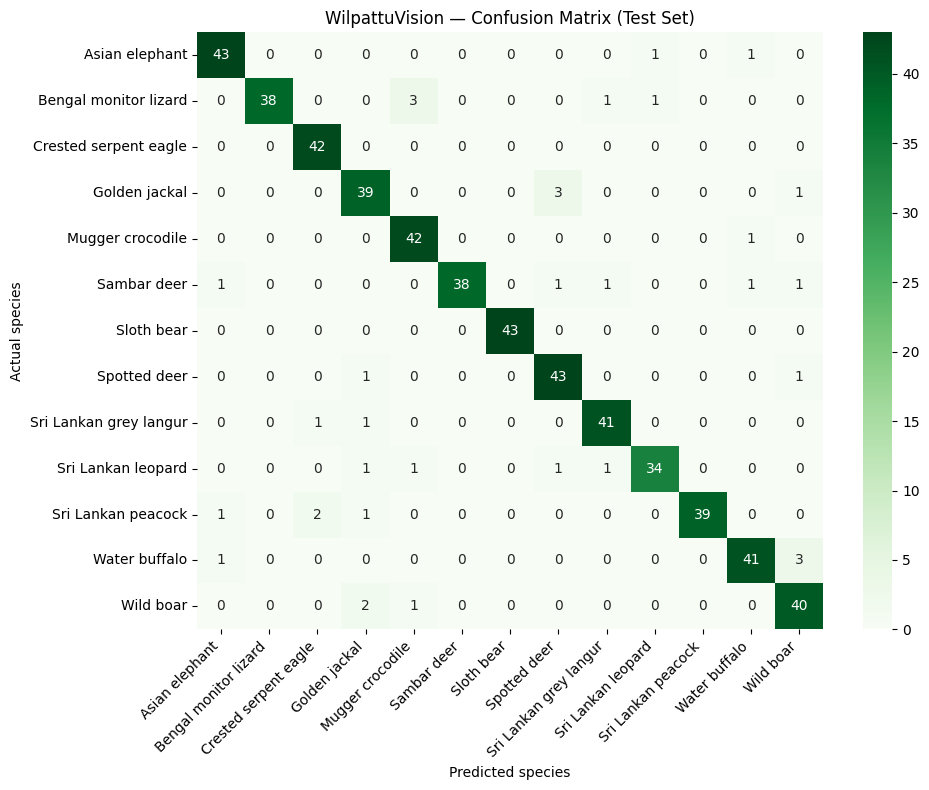

Saved confusion matrix to /content/drive/MyDrive/WilpattuVision/model/confusion_matrix.png

Per-class check against the 80% target:
  Asian elephant                 precision=0.93  recall=0.96
  Bengal monitor lizard          precision=1.00  recall=0.88
  Crested serpent eagle          precision=0.93  recall=1.00
  Golden jackal                  precision=0.87  recall=0.91
  Mugger crocodile               precision=0.89  recall=0.98
  Sambar deer                    precision=1.00  recall=0.88
  Sloth bear                     precision=1.00  recall=1.00
  Spotted deer                   precision=0.90  recall=0.96
  Sri Lankan grey langur         precision=0.93  recall=0.95
  Sri Lankan leopard             precision=0.94  recall=0.89
  Sri Lankan peacock             precision=1.00  recall=0.91
  Water buffalo                  precision=0.93  recall=0.91
  Wild boar                      precision=0.87  recall=0.93

Final model exported to: /content/drive/MyDrive/WilpattuVision/model/wilpa

In [ ]:


import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

                                                                           
PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
MODEL_DIR = os.path.join(PROJECT_DIR, 'model')

IMG_SIZE = (300, 300)
BATCH_SIZE = 16

CHECKPOINT_PATH = os.path.join(MODEL_DIR, 'best_checkpoint.keras')
LABEL_MAP_PATH = os.path.join(MODEL_DIR, 'label_map.json')
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, 'wilpattu_species_model.keras')
REPORT_PATH = os.path.join(MODEL_DIR, 'classification_report.txt')
CONFUSION_MATRIX_PATH = os.path.join(MODEL_DIR, 'confusion_matrix.png')


                                                                           
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False,                                                 
)
class_names = test_ds.class_names                                                


                                                                          
                                                                        
                                                                      
                                                                     
                                                                    
                                                                   
                                                   
with open(LABEL_MAP_PATH) as f:
    saved_label_map = json.load(f)
expected_order = [saved_label_map[str(i)] for i in range(len(saved_label_map))]

if class_names != expected_order:
    raise ValueError(
        "Test set class order does not match label_map.json -- STOPPING "
        "before computing any metrics, since proceeding would silently "
        "compare predictions against the wrong species.\n"
        f"  label_map.json order: {expected_order}\n"
        f"  test set order:       {class_names}\n"
        "Check that data/test/ contains exactly the same species "
        "subfolders, with the same names, as data/train/ did when "
        "03_train_model.py ran."
    )
print("Test set class order matches label_map.json exactly. Safe to proceed.\n")

                                                                        
                                                                        
                                                                        
display_names = [name.replace("_", " ") for name in class_names]


                                                                            
print(f"{'Species':30s} {'Test images':>12s}")
for folder_name, display_name in zip(class_names, display_names):
    count = len([
        f for f in os.listdir(os.path.join(DATA_DIR, 'test', folder_name))
        if os.path.isfile(os.path.join(DATA_DIR, 'test', folder_name, f))
    ])
    flag = "  <-- small test set, treat its score with caution" if count < 20 else ""
    print(f"{display_name:30s} {count:>12d}{flag}")
print()


                                                                          
model = tf.keras.models.load_model(CHECKPOINT_PATH)


                                                                          
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


                                                                          
test_accuracy = (y_true == y_pred).mean()
print(f"Overall test accuracy: {test_accuracy:.2%}\n")


                                                                             
report = classification_report(
    y_true, y_pred, target_names=display_names, digits=3
)
print(report)

with open(REPORT_PATH, 'w') as f:
    f.write(f"Overall test accuracy: {test_accuracy:.2%}\n\n")
    f.write(report)
print(f"Saved classification report to {REPORT_PATH}")


                                                                           
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=display_names, yticklabels=display_names,
)
plt.xlabel('Predicted species')
plt.ylabel('Actual species')
plt.title('WilpattuVision — Confusion Matrix (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=150)
plt.show()
print(f"Saved confusion matrix to {CONFUSION_MATRIX_PATH}")


                                                                          
print("\nPer-class check against the 80% target:")
report_dict = classification_report(
    y_true, y_pred, target_names=display_names, output_dict=True
)
for display_name in display_names:
    metrics = report_dict[display_name]
    flag = ""
    if metrics['precision'] < 0.80 or metrics['recall'] < 0.80:
        flag = "  <-- BELOW 80% TARGET"
    print(f"  {display_name:30s} precision={metrics['precision']:.2f}  "
          f"recall={metrics['recall']:.2f}{flag}")


                                                                           
model.save(FINAL_MODEL_PATH)
print(f"\nFinal model exported to: {FINAL_MODEL_PATH}")
print(f"Label map already verified consistent at the start of this script: "
      f"{LABEL_MAP_PATH}")


In [ ]:


import os
import json
import numpy as np
import tensorflow as tf

                                                                           
PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
MODEL_DIR = os.path.join(PROJECT_DIR, 'model')

MODEL_PATH = os.path.join(MODEL_DIR, 'wilpattu_species_model.keras')
LABEL_MAP_PATH = os.path.join(MODEL_DIR, 'label_map.json')
IMG_SIZE = (300, 300)

                                                                      
                             
ROBUSTNESS_TEST_DIR = os.path.join(PROJECT_DIR, 'robustness_test_images')

                                                                     
                                                                   
                                                                      
                                                                     
                                    
CONFIDENCE_THRESHOLD = 0.60

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp'}


def load_label_map():
    with open(LABEL_MAP_PATH) as f:
        raw = json.load(f)
    return {int(k): v.replace("_", " ") for k, v in raw.items()}


def predict_single(model, label_map, image_path, top_k=3):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]
    top_indices = predictions.argsort()[::-1][:top_k]

    return [(label_map[idx], float(predictions[idx])) for idx in top_indices]


def main():
    if not os.path.isdir(ROBUSTNESS_TEST_DIR):
        print(f"Folder not found: {ROBUSTNESS_TEST_DIR}")
        print("Create it in Google Drive and add some test images first "
              "(see the guidance in this script's docstring for what "
              "kinds of images to include).")
        return

    image_files = sorted([
        f for f in os.listdir(ROBUSTNESS_TEST_DIR)
        if os.path.splitext(f)[1].lower() in VALID_EXTENSIONS
    ])

    if not image_files:
        print(f"No image files found in {ROBUSTNESS_TEST_DIR}")
        return

    print(f"Loading model and testing {len(image_files)} image(s)...\n")
    model = tf.keras.models.load_model(MODEL_PATH)
    label_map = load_label_map()

    results = []
    for fname in image_files:
        fpath = os.path.join(ROBUSTNESS_TEST_DIR, fname)
        top3 = predict_single(model, label_map, fpath)
        results.append((fname, top3))

                                                                          
                                                                         
                                        
    results.sort(key=lambda r: r[1][0][1])

    print(f"{'Image':35s} {'Top prediction':25s} {'Conf.':>7s}  Flag")
    print("-" * 85)
    for fname, top3 in results:
        top_species, top_conf = top3[0]
        flag = "UNCERTAIN" if top_conf < CONFIDENCE_THRESHOLD else ""
        print(f"{fname:35s} {top_species:25s} {top_conf:>6.1%}  {flag}")

                                                                      
                                                                        
                                         
    flagged = [(f, t) for f, t in results if t[0][1] < CONFIDENCE_THRESHOLD]
    if flagged:
        print(f"\n{len(flagged)} image(s) below the "
              f"{CONFIDENCE_THRESHOLD:.0%} threshold -- full top-3 breakdown:\n")
        for fname, top3 in flagged:
            print(f"  {fname}:")
            for rank, (species, conf) in enumerate(top3, start=1):
                print(f"    {rank}. {species:25s} {conf:.1%}")
            print()
    else:
        print(f"\nNo images fell below the {CONFIDENCE_THRESHOLD:.0%} "
              f"threshold. If you included genuinely unrelated images "
              f"(a giraffe, an empty landscape) and they're NOT flagged, "
              f"your threshold is probably set too low -- raise "
              f"CONFIDENCE_THRESHOLD and re-run.")



if __name__ == "__main__":
    main()

Loading model and testing 11 image(s)...

Image                               Top prediction              Conf.  Flag
-------------------------------------------------------------------------------------
dog.jpg                             Spotted deer               16.2%  UNCERTAIN
car.jpg                             Sloth bear                 21.4%  UNCERTAIN
horse.jpg                           Sambar deer                42.6%  UNCERTAIN
giraffe.jpg                         Spotted deer               46.0%  UNCERTAIN
trees.jpg                           Spotted deer               59.1%  UNCERTAIN
rhino.jpg                           Asian elephant             59.6%  UNCERTAIN
grizzly.jpg                         Sloth bear                 64.0%  
rscat.jpg                           Sri Lankan leopard         70.3%  
komodo.webp                         Bengal monitor lizard      90.8%  
whitepeaock.jpg                     Sri Lankan peacock         99.6%  
swcroc.jpg                      

In [ ]:
!python --version


Python 3.12.13


In [ ]:


import os
import json
import numpy as np
import tensorflow as tf

                                                                           
PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
MODEL_DIR = os.path.join(PROJECT_DIR, 'model')

MODEL_PATH = os.path.join(MODEL_DIR, 'wilpattu_species_model.keras')
LABEL_MAP_PATH = os.path.join(MODEL_DIR, 'label_map.json')
IMG_SIZE = (300, 300)


def load_label_map():
    with open(LABEL_MAP_PATH) as f:
        raw = json.load(f)
                                                                            
    return {int(k): v.replace("_", " ") for k, v in raw.items()}


def predict(image_path, top_k=3):
    model = tf.keras.models.load_model(MODEL_PATH)
    label_map = load_label_map()

    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)                   

    predictions = model.predict(img_array, verbose=0)[0]
    top_indices = predictions.argsort()[::-1][:top_k]

    print(f"\nPredictions for: {os.path.basename(image_path)}\n")
    for rank, idx in enumerate(top_indices, start=1):
        species = label_map[idx]
        confidence = predictions[idx] * 100
        print(f"  {rank}. {species:30s} {confidence:.1f}%")

    return [(label_map[idx], float(predictions[idx])) for idx in top_indices]


def predict_from_upload(top_k=3):
    """Option A -- pops up a file picker to upload a photo directly from
    your computer, then runs the same prediction as predict()."""
    from google.colab import files
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded.")
        return None
    image_path = list(uploaded.keys())[0]
    return predict(image_path, top_k=top_k)


if __name__ == "__main__":
                                                                           
    predict_from_upload()

                                                                      
                                               
                                                                              
                              


Saving Sambar_deer_SL_0131.jpg to Sambar_deer_SL_0131 (1).jpg

Predictions for: Sambar_deer_SL_0131 (1).jpg

  1. Sambar deer                    99.8%
  2. Spotted deer                   0.1%
  3. Asian elephant                 0.0%
